<a href="https://colab.research.google.com/github/voroshilovmikhail7/Quantum-systems/blob/main/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-425009660.py:106: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(psi**2, dx=dx))
/tmp/ipython-input-425009660.py:111: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz((psi**2) * U, dx=dx))


=== WELL 1 ===
E0_1      = -1.8175046319
<U_f>_1   = -2.8421120115
<U_g>_1   = 0.8505345624
dE1/df HF = -0.9473706705
dE1/dg HF = 0.8505345624

=== WELL 2 ===
E0_2      = -1.9151141431
<U_f>_2   = -2.8657724250
<U_g>_2   = 0.7875924225
dE2/df HF = -0.9552574750
dE2/dg HF = 0.7875924225

=== TRANSITION (2 - 1) ===
ΔE        = -0.0976095112
K_f       = 0.2423986471
K_g       = 0.6448361352


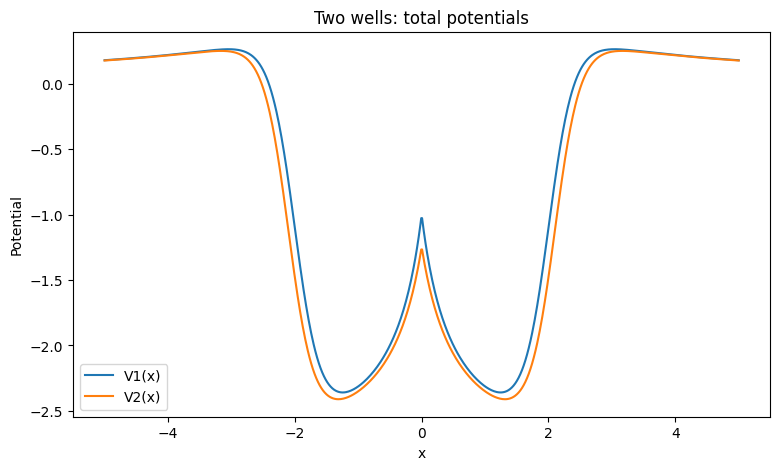

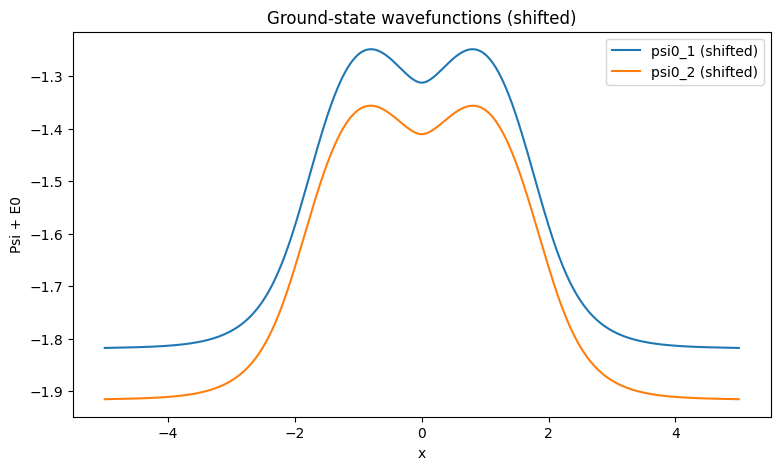

In [ ]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# ============================================================
# 0) НАСТРОЙКИ: задаёшь ОДИН РАЗ здесь, без input() при запуске
# ============================================================

# --- Сетка (можно менять под задачу)
GRID = dict(x_min=-5.0, x_max=5.0, N=750)

# --- Общие константы связи (ОДНИ И ТЕ ЖЕ для двух ям)
# (в модели U_f линейно по f, U_g линейно по g)
f = 3.0   # глубина сильной ямы
g = 1.0    # высота/масштаб "электромагнитного" бугра

# --- Выбор типа U_g(x):
# 1 - Gauss-type
# 2 - Lorentz-type
# 3 - Coulomb-type (uniform charged sphere; "C")
# 4 - Coulomb-Newton ("CN")  <-- добавлено
potential_type = 4

# --- Параметры потенциала 1 (яма 1)
POT1 = dict(
    w=2.0,   # half-width
    s=0.20,   # skin-layer thickness
    t=0.50    # half-width параметр для U_g
)

# --- Параметры потенциала 2 (яма 2)
POT2 = dict(
    w=2.1,   # half-width
    s=0.20,   # skin-layer thickness
    t=0.57    # half-width параметр для U_g
)

# --- Графики
PLOT = dict(show=True)

# ============================================================
# 1) МОДЕЛЬ ПОТЕНЦИАЛОВ
# ============================================================

def select_potential(x: np.ndarray, g: float, t: float, potential_type: int) -> np.ndarray:
    """
    U_g(x) = g * shape(x,t)
    1: Gauss-type       ~ exp(-(x/t)^2)
    2: Lorentz-type     ~ 1/(1+(x/t)^2)
    3: Coulomb-type (C) uniform charged sphere (piecewise)
    4: Coulomb-Newton (CN): g/(|x|+t)  (простая регуляризация 1/|x|)
    """
    ax = np.abs(x)

    if potential_type == 1:
        return g * np.exp(-(x / t) ** 2)

    elif potential_type == 2:
        return g / (1.0 + (x / t) ** 2)

    elif potential_type == 3:
        # Coulomb-type (uniform charged sphere):
        # outside: g/|x|
        # inside:  g*(3 - (x/t)^2)/(2t)
        return np.where(ax >= t, g / ax, g * (3.0 - (x / t) ** 2) / (2.0 * t))

    elif potential_type == 4:
        # Coulomb-Newton (CN): регуляризованный ньютоновский/кулоновский вид
        # (устраняет сингулярность в x=0)
        return g / (ax + t)

    else:
        raise ValueError("Invalid potential_type. Choose 1 (Gauss), 2 (Lorentz), 3 (C), 4 (CN).")


def potential_total(x: np.ndarray, f: float, w: float, s: float,
                    g: float, t: float, potential_type: int):
    """
    U_f(x) = -f / (1 + exp((|x|-w)/s))   (симметризованный Woods–Saxon)
    U_g(x) = select_potential(...)
    """
    U_f = -f / (1.0 + np.exp((np.abs(x) - w) / s))
    U_g = select_potential(x, g, t, potential_type)
    V = U_f + U_g
    return V, U_f, U_g


# ============================================================
# 2) ШРЁДИНГЕР (конечные разности)
# ============================================================

def solve_schrodinger_1d(x: np.ndarray, V: np.ndarray, dx: float):
    N = len(x)
    H = np.zeros((N, N), dtype=float)

    coeff = -0.5 / dx**2
    np.fill_diagonal(H, -2.0 * coeff + V)
    np.fill_diagonal(H[:-1, 1:], coeff)
    np.fill_diagonal(H[1:, :-1], coeff)

    E, psi = la.eigh(H)          # E по возрастанию, psi[:, i] — i-е собственное
    return E, psi


def normalize(psi: np.ndarray, dx: float) -> np.ndarray:
    norm = np.sqrt(np.trapz(psi**2, dx=dx))
    return psi / norm


def expectation_value(psi: np.ndarray, U: np.ndarray, dx: float) -> float:
    return float(np.trapz((psi**2) * U, dx=dx))


# ============================================================
# 3) РАСЧЁТ ДЛЯ ОДНОЙ ЯМЫ + HF (без численных производных)
# ============================================================

def compute_well(x: np.ndarray, dx: float, f: float, g: float,
                 w: float, s: float, t: float, potential_type: int):
    V, U_f, U_g = potential_total(x, f, w, s, g, t, potential_type)
    E, psi = solve_schrodinger_1d(x, V, dx)

    psi0 = normalize(psi[:, 0], dx)
    Uf_avg = expectation_value(psi0, U_f, dx)
    Ug_avg = expectation_value(psi0, U_g, dx)

    # По G-F th (линейность по f,g):
    dE_df = Uf_avg / f if f != 0 else np.nan
    dE_dg = Ug_avg / g if g != 0 else np.nan

    return dict(
        E0=float(E[0]),
        psi0=psi0,
        V=V,
        U_f=U_f,
        U_g=U_g,
        Uf_avg=Uf_avg,
        Ug_avg=Ug_avg,
        dE_df=dE_df,
        dE_dg=dE_dg
    )


# ============================================================
# 4) ΔE И КОЭФФИЦИЕНТЫ УСИЛЕНИЯ K_f, K_g ДЛЯ ДВУХ ЯМ
# ============================================================

def enhancement_factors(res1: dict, res2: dict, f: float, g: float):
    """
    ΔE = E2 - E1  (как в статье — переход между двумя уровнями)
    K_f = (f/ΔE) * d(ΔE)/df = (f/ΔE) * (dE2/df - dE1/df)
    K_g = (g/ΔE) * d(ΔE)/dg = (g/ΔE) * (dE2/dg - dE1/dg)
    """
    dE = res2["E0"] - res1["E0"]
    d_dE_df = res2["dE_df"] - res1["dE_df"]
    d_dE_dg = res2["dE_dg"] - res1["dE_dg"]

    if dE == 0:
        Kf = np.inf * np.sign(d_dE_df) if d_dE_df != 0 else np.nan
        Kg = np.inf * np.sign(d_dE_dg) if d_dE_dg != 0 else np.nan
    else:
        Kf = (f / dE) * d_dE_df
        Kg = (g / dE) * d_dE_dg

    return dict(DeltaE=dE, Kf=Kf, Kg=Kg)


# ============================================================
# 5) MAIN
# ============================================================

def main():
    # Сетка
    x = np.linspace(GRID["x_min"], GRID["x_max"], GRID["N"])
    dx = x[1] - x[0]

    # Две ямы
    res1 = compute_well(x, dx, f, g, POT1["w"], POT1["s"], POT1["t"], potential_type)
    res2 = compute_well(x, dx, f, g, POT2["w"], POT2["s"], POT2["t"], potential_type)

    enh = enhancement_factors(res1, res2, f, g)

    # Печать результатов (без кинетики и без численных производных средних)
    print("=== WELL 1 ===")
    print(f"E0_1      = {res1['E0']:.10f}")
    print(f"<U_f>_1   = {res1['Uf_avg']:.10f}")
    print(f"<U_g>_1   = {res1['Ug_avg']:.10f}")
    print(f"dE1/df HF = {res1['dE_df']:.10f}")
    print(f"dE1/dg HF = {res1['dE_dg']:.10f}")

    print("\n=== WELL 2 ===")
    print(f"E0_2      = {res2['E0']:.10f}")
    print(f"<U_f>_2   = {res2['Uf_avg']:.10f}")
    print(f"<U_g>_2   = {res2['Ug_avg']:.10f}")
    print(f"dE2/df HF = {res2['dE_df']:.10f}")
    print(f"dE2/dg HF = {res2['dE_dg']:.10f}")

    print("\n=== TRANSITION (2 - 1) ===")
    print(f"ΔE        = {enh['DeltaE']:.10f}")
    print(f"K_f       = {enh['Kf']:.10f}")
    print(f"K_g       = {enh['Kg']:.10f}")

    # Графики
    if PLOT.get("show", True):
        plt.figure(figsize=(9, 5))
        plt.plot(x, res1["V"], label="V1(x)")
        plt.plot(x, res2["V"], label="V2(x)")
        plt.xlabel("x")
        plt.ylabel("Potential")
        plt.legend()
        plt.title("Two wells: total potentials")
        plt.show()

        plt.figure(figsize=(9, 5))
        plt.plot(x, res1["psi0"] + res1["E0"], label="psi0_1 (shifted)")
        plt.plot(x, res2["psi0"] + res2["E0"], label="psi0_2 (shifted)")
        plt.xlabel("x")
        plt.ylabel("Psi + E0")
        plt.legend()
        plt.title("Ground-state wavefunctions (shifted)")
        plt.show()


if __name__ == "__main__":
    main()


w grid: 0.01 .. 4.5  (Nw=450, step=0.01)
t grid: 0.05 .. 5.0  (Nt=496, step=0.01)


/tmp/ipython-input-2571127754.py:106: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(psi**2, dx=dx))
/tmp/ipython-input-2571127754.py:111: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz((psi**2) * U, dx=dx))


Row 1/450 done (w=0.01)
Row 45/450 done (w=0.45)
Row 90/450 done (w=0.9)
Row 135/450 done (w=1.35)
Row 180/450 done (w=1.8)
Row 225/450 done (w=2.25)
Row 270/450 done (w=2.7)
Row 315/450 done (w=3.15)
Row 360/450 done (w=3.6)
Row 405/450 done (w=4.05)
Row 450/450 done (w=4.5)


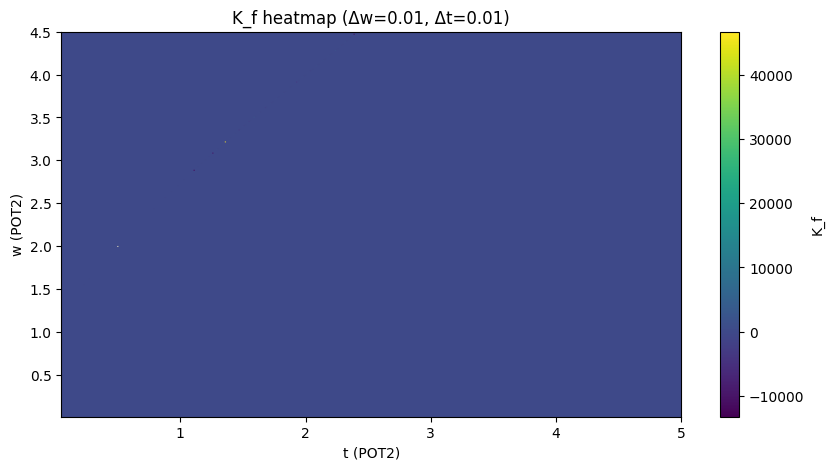

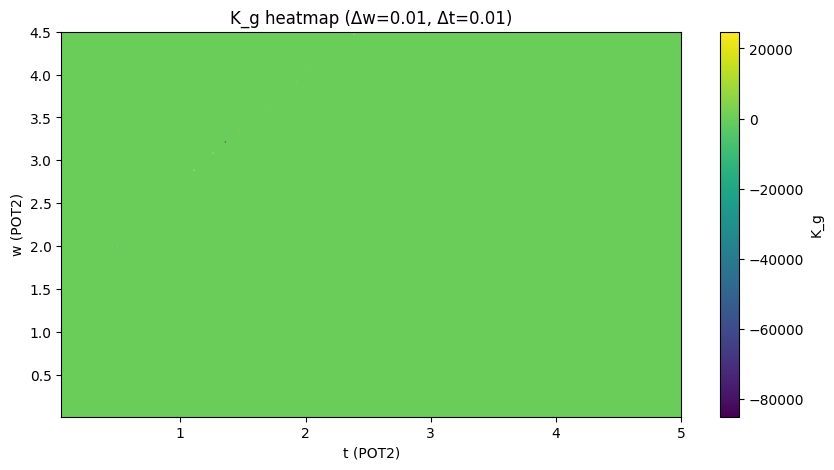

In [ ]:
# ============================================================
# 6) СКАНИРОВАНИЕ (w, t) и ТЕПЛОВЫЕ КАРТЫ K_f, K_g
#    Вариация: МЕНЯЕМ (w,t) ТОЛЬКО ДЛЯ POT2, POT1 фиксирована.
#    Все диапазоны и шаги задаются ВВЕРХУ в SCAN.
# ============================================================

# --- Настройки сканирования (меняй здесь)
SCAN = dict(
    w_min=0.01,
    w_max=4.5,
    w_step=0.01,
    t_min=0.05,
    t_max=5.0,
    t_step=0.01,
    eps_deltaE=1e-10,
    round_nd=12,   # округление для стабилизации сетки
)

def make_grid(vmin: float, vmax: float, step: float, round_nd: int = 12):
    """
    Возвращает массив значений от vmin до vmax включительно с шагом step,
    с защитой от float-ошибок и без "вылета" за vmax.
    """
    if step <= 0:
        raise ValueError("step must be > 0")
    vals = np.arange(vmin, vmax + 0.5 * step, step, dtype=float)
    vals = vals[vals <= vmax + 1e-12]
    if round_nd is not None:
        vals = np.round(vals, int(round_nd))
    return vals

def solve_ground_state_tridiag(V: np.ndarray, dx: float):
    """
    Быстрый решатель для ТОЛЬКО основного состояния для симметричной трёхдиагональной матрицы.
    H = -1/2 d2/dx2 + V(x)
    """
    off = -0.5 / dx**2
    d = (1.0 / dx**2) + V
    e = np.full(V.size - 1, off, dtype=float)

    E, Z = la.eigh_tridiagonal(d, e, select='i', select_range=(0, 0))
    psi0 = Z[:, 0]
    return float(E[0]), psi0

def compute_well_ground_fast(x: np.ndarray, dx: float, f: float, g: float,
                             w: float, s: float, t: float, potential_type: int):
    """
    Считает ТОЛЬКО основное состояние
    Возвращает E0, <U_f>, <U_g>, dE/df, dE/dg (HF).
    Требует, чтобы в первой части уже были:
      potential_total, normalize, expectation_value
    """
    V, U_f, U_g = potential_total(x, f, w, s, g, t, potential_type)

    E0, psi0 = solve_ground_state_tridiag(V, dx)
    psi0 = normalize(psi0, dx)

    Uf_avg = expectation_value(psi0, U_f, dx)
    Ug_avg = expectation_value(psi0, U_g, dx)

    dE_df = Uf_avg / f if f != 0 else np.nan
    dE_dg = Ug_avg / g if g != 0 else np.nan

    return dict(E0=E0, Uf_avg=Uf_avg, Ug_avg=Ug_avg, dE_df=dE_df, dE_dg=dE_dg)

def scan_w_t_and_plot():
    # Сетка
    x = np.linspace(GRID["x_min"], GRID["x_max"], GRID["N"])
    dx = x[1] - x[0]

    # Диапазоны/шаги из SCAN
    w_vals = make_grid(SCAN["w_min"], SCAN["w_max"], SCAN["w_step"], SCAN["round_nd"])
    t_vals = make_grid(SCAN["t_min"], SCAN["t_max"], SCAN["t_step"], SCAN["round_nd"])

    print(f"w grid: {w_vals[0]} .. {w_vals[-1]}  (Nw={len(w_vals)}, step={SCAN['w_step']})")
    print(f"t grid: {t_vals[0]} .. {t_vals[-1]}  (Nt={len(t_vals)}, step={SCAN['t_step']})")

    # 1) WELL 1 один раз (фиксирована)
    res1 = compute_well_ground_fast(
        x, dx, f, g,
        POT1["w"], POT1["s"], POT1["t"],
        potential_type
    )

    # 2) Карты для K_f и K_g
    Kf_map = np.full((len(w_vals), len(t_vals)), np.nan, dtype=float)
    Kg_map = np.full((len(w_vals), len(t_vals)), np.nan, dtype=float)

    EPS_DE = float(SCAN["eps_deltaE"])

    # 3) Сканируем (w2, t2) для WELL 2
    for i, w2 in enumerate(w_vals):
        for j, t2 in enumerate(t_vals):
            res2 = compute_well_ground_fast(
                x, dx, f, g,
                float(w2), POT2["s"], float(t2),
                potential_type
            )

            dE = res2["E0"] - res1["E0"]
            if abs(dE) < EPS_DE:
                continue

            d_dE_df = res2["dE_df"] - res1["dE_df"]
            d_dE_dg = res2["dE_dg"] - res1["dE_dg"]

            Kf_map[i, j] = (f / dE) * d_dE_df
            Kg_map[i, j] = (g / dE) * d_dE_dg

        if (i + 1) % max(1, len(w_vals)//10) == 0 or i == 0 or i == len(w_vals) - 1:
            print(f"Row {i+1}/{len(w_vals)} done (w={w2})")

    # 4) Тепловые карты
    extent = [t_vals[0], t_vals[-1], w_vals[0], w_vals[-1]]

    plt.figure(figsize=(10, 5))
    plt.imshow(Kf_map, origin="lower", aspect="auto", extent=extent)
    plt.colorbar(label="K_f")
    plt.xlabel("t (POT2)")
    plt.ylabel("w (POT2)")
    plt.title(f"K_f heatmap (Δw={SCAN['w_step']}, Δt={SCAN['t_step']})")
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.imshow(Kg_map, origin="lower", aspect="auto", extent=extent)
    plt.colorbar(label="K_g")
    plt.xlabel("t (POT2)")
    plt.ylabel("w (POT2)")
    plt.title(f"K_g heatmap (Δw={SCAN['w_step']}, Δt={SCAN['t_step']})")
    plt.show()

    return Kf_map, Kg_map, w_vals, t_vals

# Запуск
Kf_map, Kg_map, w_vals, t_vals = scan_w_t_and_plot()


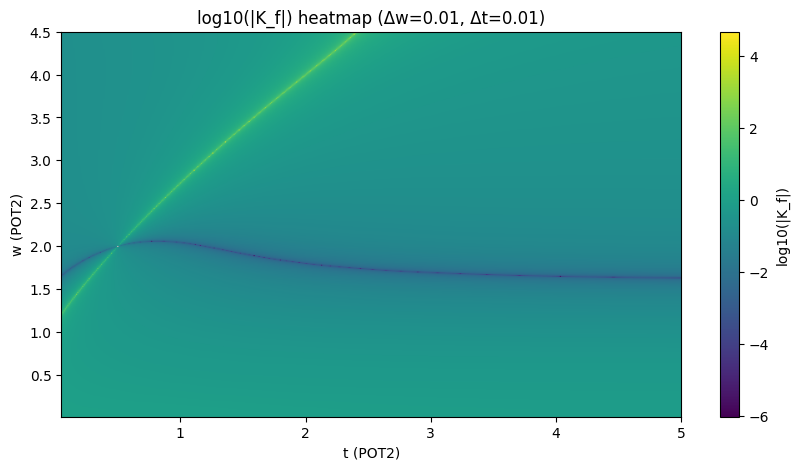

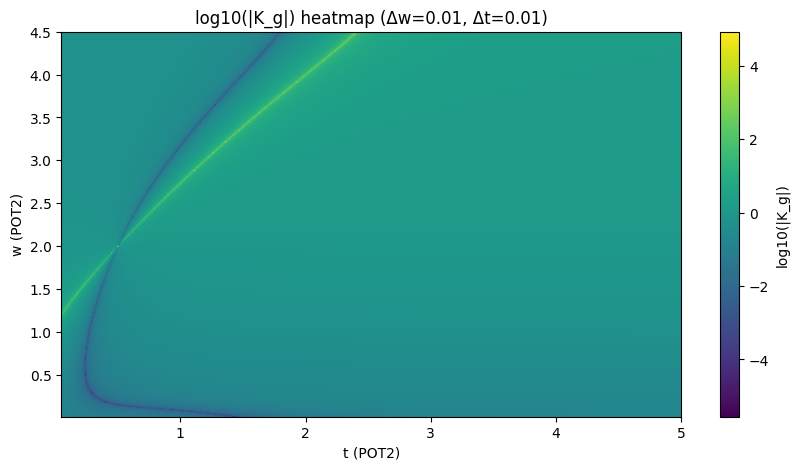

In [ ]:
# 5) Тепловые карты (логарифм модуля коэффициента усиления)
extent = [t_vals[0], t_vals[-1], w_vals[0], w_vals[-1]]

# логарифм по основанию 10 от |K|, избегаем log(0)
tiny = 1e-300  # чтобы не было -inf при нулевых значениях
logKf_map = np.log10(np.maximum(np.abs(Kf_map), tiny))
logKg_map = np.log10(np.maximum(np.abs(Kg_map), tiny))

# (опционально) замаскировать там, где исходно NaN
logKf_map = np.where(np.isfinite(Kf_map), logKf_map, np.nan)
logKg_map = np.where(np.isfinite(Kg_map), logKg_map, np.nan)

plt.figure(figsize=(10, 5))
plt.imshow(logKf_map, origin="lower", aspect="auto", extent=extent)
plt.colorbar(label="log10(|K_f|)")
plt.xlabel("t (POT2)")
plt.ylabel("w (POT2)")
plt.title(f"log10(|K_f|) heatmap (Δw={SCAN['w_step']}, Δt={SCAN['t_step']})")
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(logKg_map, origin="lower", aspect="auto", extent=extent)
plt.colorbar(label="log10(|K_g|)")
plt.xlabel("t (POT2)")
plt.ylabel("w (POT2)")
plt.title(f"log10(|K_g|) heatmap (Δw={SCAN['w_step']}, Δt={SCAN['t_step']})")
plt.show()
